In [3]:
#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils import data
from torchvision import datasets,transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from transformers.convert_slow_tokenizer import import_protobuf

USE_MPS = torch.backends.mps.is_available()
DEVICE=torch.device('mps' if USE_MPS else 'cpu')

# DCGAN 모델 생성

In [ ]:
BATCH_SIZE = 128
EPOCHS = 30

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)) # [-1, 1]
])
tr_ds = datasets.MNIST(root='../../data', train=True, transform=transform, download=True)
tr_ds_loader = data.DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [ ]:
Z_DIM = 3
IMG_C = 1
IMG_SIZE = 28

In [ ]:
D = nn.Sequential(
    nn.Conv2d(IMG_C, 64, 4, 2, 1, bias=False), #[64, 14, 14]
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(64, 128, 4, 2, 1, bias=False), #[128, 7, 7]
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Flatten(),
    nn.Linear(128 * 7 * 7, 1),
    nn.Sigmoid()
)

In [ ]:
G = nn.Sequential(
    nn.Linear(Z_DIM, 128*7*7),
    nn.BatchNorm1d(128*7*7),
    nn.ReLU(),
    nn.Unflatten(1, (128, 7, 7)), #[128, 7, 7]
    nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), #[64, 14, 14]
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.ConvTranspose2d(64, IMG_C, 4, 2, 1, bias=False), #[1, 28, 28]
    nn.Tanh()
)

In [ ]:
G = G.to(DEVICE)
D = D.to(DEVICE)

In [ ]:
criterion = nn.BCELoss()
d_opt = optim.Adam(D.parameters(), lr=0.0002)
g_opt = optim.Adam(G.parameters(), lr=0.0002)

In [ ]:
z_noise = torch.randn(BATCH_SIZE, Z_DIM, device=DEVICE)
for epoch in range(EPOCHS):
    for i, (x, _) in enumerate(tr_ds_loader):
        data = x.to(DEVICE)
        # data.size[0] 배치 사이즈
        r_label = torch.ones(BATCH_SIZE, 1, device=DEVICE)
        f_label = torch.zeros(BATCH_SIZE, 1, device=DEVICE)

        z = torch.randn(BATCH_SIZE, Z_DIM, device=DEVICE)
        f_img = G(z)

        real_out = D(data)
        d_loss_real = criterion(real_out, r_label)
        real_sc = real_out.detach()

        fake_out = D(f_img.detach())
        d_loss_fake = criterion(fake_out, f_label)
        fake_sc = fake_out.detach()

        d_loss = d_loss_real + d_loss_fake

        g_opt.zero_grad()
        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        fake_out_ck_g = D(f_img)
        g_loss = criterion(fake_out_ck_g, r_label)

        g_opt.zero_grad()
        d_opt.zero_grad()
        g_loss.backward()
        g_opt.step()
    print(f'{epoch+1} 회, d_loss: {d_loss.item()}, g_loss: {g_loss.item()} D(G(z)): {fake_sc.mean().item()} D(x): {real_sc.mean().item()}')

    with torch.no_grad():
        G.eval()
        v_img = G(z_noise) #(64, 1, 28, 28)
        v_img = (v_img+1)/2

        f, a = plt.subplots(8, 8, figsize=(8, 8))
        for i, ax in enumerate(a.flat):
            img = v_img[i].cpu().permute(1, 2, 0).numpy()
            ax.imshow(img.squeeze(), cmap='gray')
            ax.axis('off')
        plt.tight_layout()
        plt.show()
        G.train()

# 패션 데이터를 이용하여 DCGAN을 구현하시오

In [ ]:
from torch.utils import data
from torchvision import datasets,transforms

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)) # [-1, 1]
])
tr_ds = datasets.FashionMNIST(root='../../data', train=True, transform=transform, download=True)
tr_ds_loader = data.DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [ ]:
Z_DIM = 300
IMG_C = 1
IMG_SIZE = 28

In [ ]:
D = nn.Sequential(
    nn.Conv2d(IMG_C, 64, 4, 2, 1, bias=False),  #[64, 14, 14]
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(64, 128, 4, 2, 1, bias=False),  #[128, 7, 7]
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Flatten(),
    nn.Linear(128 * 7 * 7, 1),
    nn.Sigmoid()
)
G = nn.Sequential(
    nn.Linear(Z_DIM, 128 * 7 * 7),
    nn.BatchNorm1d(128 * 7 * 7),
    nn.ReLU(),
    nn.Unflatten(1, (128, 7, 7)),  #[128, 7, 7]
    nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),  #[64, 14, 14]
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.ConvTranspose2d(64, IMG_C, 4, 2, 1, bias=False),  #[1, 28, 28]
    nn.Tanh()
)

In [ ]:
G = G.to(DEVICE)
D = D.to(DEVICE)
criterion = nn.BCELoss()
d_opt = optim.Adam(D.parameters(), lr=0.0002)
g_opt = optim.Adam(G.parameters(), lr=0.0002)

In [ ]:
z_noise = torch.randn(BATCH_SIZE, Z_DIM, device=DEVICE)
for epoch in range(EPOCHS):
    for i, (x, _) in enumerate(tr_ds_loader):
        data = x.to(DEVICE)
        # data.size[0] 배치 사이즈
        r_label = torch.ones(BATCH_SIZE, 1, device=DEVICE)
        f_label = torch.zeros(BATCH_SIZE, 1, device=DEVICE)

        z = torch.randn(BATCH_SIZE, Z_DIM, device=DEVICE)
        f_img = G(z)

        real_out = D(data)
        d_loss_real = criterion(real_out, r_label)
        real_sc = real_out.detach()

        fake_out = D(f_img.detach())
        d_loss_fake = criterion(fake_out, f_label)
        fake_sc = fake_out.detach()

        d_loss = d_loss_real + d_loss_fake

        g_opt.zero_grad()
        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        fake_out_ck_g = D(f_img)
        g_loss = criterion(fake_out_ck_g, r_label)

        g_opt.zero_grad()
        d_opt.zero_grad()
        g_loss.backward()
        g_opt.step()
    print(
        f'{epoch + 1} 회, d_loss: {d_loss.item()}, g_loss: {g_loss.item()} D(G(z)): {fake_sc.mean().item()} D(x): {real_sc.mean().item()}')

    with torch.no_grad():
        G.eval()
        v_img = G(z_noise)  #(64, 1, 28, 28)
        v_img = (v_img + 1) / 2

        f, a = plt.subplots(8, 8, figsize=(8, 8))
        for i, ax in enumerate(a.flat):
            img = v_img[i].cpu().permute(1, 2, 0).numpy()
            ax.imshow(img.squeeze(), cmap='gray')
            ax.axis('off')
        plt.tight_layout()
        plt.show()
        G.train()

# 데이터 로드

In [ ]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

IMG_SIZE = 128
BATCH_SIZE = 32
transform = transforms.Compose([
    # 데이터 증강
    # 이미지 크기 resize
    transforms.Resize(IMG_SIZE),
    # 텐서화
    transforms.ToTensor(),
    # 스케일 정리
    # 이미지 net 의 데이터 기본 처리 방식
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.334, 0.225))
])
tr_ds = datasets.ImageFolder(root='../../data/dogs-vs-cats_data/train', transform=transform)
tt_ds = datasets.ImageFolder(root='../../data/dogs-vs-cats_data/test', transform=transform)
val_ds = datasets.ImageFolder(root='../../data/dogs-vs-cats_data/val', transform=transform)

tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
tt_ds_loader = DataLoader(tt_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
x, y = next(iter(tr_ds_loader))

In [ ]:
import os
import shutil
import pathlib
old_dir=pathlib.Path('../../data/dogs-vs-cats_data/train')
new_dir=pathlib.Path('../../data/dogs-vs-cats_data')
def make_subset(sub_n,s_idx,e_idx):
    for i in ['cat','dog']:
        dir=new_dir/sub_n/i
        os.makedirs(dir)
        f_ns=[f'{i}.{n}.jpg' for n in range(s_idx,e_idx)]
        for f_n in f_ns:
            shutil.copyfile(src=old_dir/f_n,dst=dir/f_n)
make_subset('train',0,1000)
make_subset('val',1000,2000)
make_subset('test',2000,2500)

In [ ]:
# 대표적인 비표준
# 1. 한 폴더에 모든 클래스의 파일이 있는
# 2. 라벨이 csv파일로 정리 후 따로 저장
# 3. json 정보와 파일 정보 혼합

In [ ]:
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class F_dataset(Dataset):
    def __init__(self, path, transform):
        self.img_dir = path
        self.img_f = list(self.img_dir.glob('*.jpg'))
        if len(self.img_f) == 0:
            print('로드할 파일이 없습니다')
        self.transform = transform

    def __len__(self):
        return len(self.img_f)
    def __getitem__(self, idx):
        img_path = self.img_f[idx]

        image = Image.open(img_path).convert('RGB')

        # 내용 변경 파악
        label_name = img_path.stem.split('.')[0].lower() #cat.0.jpg
        if label_name == 'cat':
            label = 0
        elif label_name == 'dog':
            label = 1
        else:
            raise ValueError(f'파일 클래스 내용이 없는 파일이 로드되었습니다 {img_path.name}')

        if self.transform:
            image = self.transform(image)
        return image, label

base_dir = Path('../../data/dogs-vs-cats/train')
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
])
tr_ds = F_dataset(base_dir, transform)
tr_ds_loader = DataLoader(tr_ds, batch_size=4, shuffle=True)

In [ ]:
x, y = next(iter(tr_ds_loader))

In [ ]:
x.shape

In [ ]:
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms


class F_dataset(Dataset):
    def __init__(self, path, transform):
        self.img_dir = path
        self.img_f = list(self.img_dir.glob('*.jpg'))
        if len(self.img_f) == 0:
            print('로드할 파일이 없습니다')
        self.transform = transform

    def __len__(self):
        return len(self.img_f)
    def __getitem__(self, idx):
        img_path = self.img_f[idx]

        image = Image.open(img_path).convert('RGB')

        # 내용 변경 파악
        label_name = img_path.stem.split('.')[0].lower() #cat.0.jpg
        if label_name == 'cat':
            label = 0
        elif label_name == 'dog':
            label = 1
        else:
            raise ValueError(f'파일 클래스 내용이 없는 파일이 로드되었습니다 {img_path.name}')

        if self.transform:
            image = self.transform(image)
        return image, label

base_dir = Path('../../data/dogs-vs-cats/train')
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
])
all_ds = F_dataset(base_dir, transform)
all_ds_n = len(all_ds)

# 일반 권장
tr_ds_n = int(all_ds_n*.7)
tt_ds_n = int(all_ds_n*.3)
val_ds_n = int(tr_ds_n*.2)
tr_ds_n = int(tr_ds_n*.8)
print(all_ds_n,tr_ds_n, tt_ds_n, val_ds_n, tr_ds_n+tt_ds_n+val_ds_n)
tr_ds, tt_ds, val_ds = random_split(all_ds, [tr_ds_n, tt_ds_n, val_ds_n])
print(tr_ds_n, tt_ds_n, val_ds_n, len(tr_ds), len(tt_ds), len(val_ds))

tr_ds_loader = DataLoader(tr_ds, batch_size=4, shuffle=True)
tt_ds_loader = DataLoader(tt_ds, batch_size=4, shuffle=True)
val_ds_loader = DataLoader(val_ds, batch_size=4, shuffle=True)

# 디렉토리 파일을 로드 하여, class 를 활용한 DNN, CNN 모델을 구축하고 모델을 학습/추론하는 코드를 완성하시오
1. dogs-vs-cats 데이터셋을 활용하여 완성하시오
2. 데이터는 최대한 모든 데이터를 이용하시오
3. 학습, 추론은 함수로 정리하시오

## DNN


In [4]:
# import 함수
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

USE_MPS = torch.backends.mps.is_available()
DEVICE = torch.device("mps" if USE_MPS else "cpu")

In [5]:
import pathlib
from PIL import Image
import torch
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import transforms

class F_dataset(Dataset):
    def __init__(self,dir,transform=None):
        self.img_dir=dir
        self.img_f=list(self.img_dir.glob('*.jpg'))
        if len(self.img_f)==0:
            print("로드할 파일이 없습니다.")
        self.transform=transform
    def __len__(self):
        return len(self.img_f)
    def __getitem__(self,idx):
        img_path=self.img_f[idx]

        image=Image.open(img_path).convert('RGB')

        #내용 변경 파악
        label_name=img_path.stem.split('.')[0].lower() #cat.0.jpg
        if label_name=='cat':
            label=0
        elif label_name=='dog':
            label=1
        else:
            raise ValueError(f'파일 클래스 내용이 없는 파일이 로드 되었습니다{img_path.name}')

        if self.transform:
            image=self.transform(image)

        return image,label
파일이_통합되어_있는_경로=pathlib.Path('../../data/dogs-vs-cats/train')

transform=transforms.Compose([
    transforms.Resize((100,100)),
    transforms.ToTensor()
])

all_ds=F_dataset(파일이_통합되어_있는_경로,transform)
all_ds_n=len(all_ds)

#일반 권장
tr_ds_n=int(all_ds_n*0.7)
tt_ds_n=int(all_ds_n*0.3)
val_ds_n=int(tr_ds_n*0.2)
tr_ds_n=int(tr_ds_n*0.8)

tr_ds_n,tt_ds_n,val_ds_n
all_ds_n,tr_ds_n+tt_ds_n+val_ds_n
tr_ds,tt_ds,val_ds=random_split(all_ds,[tr_ds_n,tt_ds_n,val_ds_n])
tr_ds_n,tt_ds_n,val_ds_n,len(tr_ds),len(tt_ds),len(val_ds)

BATCH_SIZE = 32

tr_ds_loader=DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)
tt_ds_loader=DataLoader(tt_ds,batch_size=BATCH_SIZE,shuffle=True)
val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=True)

In [7]:
# 모델 정의
class DNN_Model(nn.Module):
    def __init__(self, input_n, hidden_ns, output_n, dropout_p=0.2):
        super().__init__()
        self.fc_in = (
            nn.Linear(input_n, hidden_ns[0]))
        self.fc_h_l = nn.ModuleList([nn.Linear(hidden_ns[i], hidden_ns[i+1]) for i in range(len(hidden_ns)-1)])
        self.fc_out = nn.Linear(hidden_ns[-1], output_n)

        self.dropout_p = dropout_p
        self.input_n = input_n
        self.hidden_ns = hidden_ns
        self.output_n = output_n

    def forward(self, x):
        # 벡터화
        x = x.view(-1, self.input_n)
        # 입력계층 연산
        x = F.relu(self.fc_in(x))
        # x = F.dropout(x, training=self.training, p=self.dropout_p)
        # 은닉계층 연산
        for i in range(len(self.fc_h_l)):
            x = F.relu(self.fc_h_l[i](x))
            # x = F.dropout(x, training=self.training, p=self.dropout_p)
        # 출력계층 연산
        out = self.fc_out(x)
        return out

In [ ]:
# 모델 학습
INPUT_SIZE = 3*100*100
model = DNN_Model(INPUT_SIZE, [256, 128, 68], 2).to(DEVICE)
opt = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)

EPOCHS=10

def train(model, tr_ds_loader, opt, epoch):
    model.train()
    for i,(x,y) in enumerate(tr_ds_loader):
        data, target = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        py = model(data)
        loss = F.cross_entropy(py, target)
        loss.backward()
        opt.step()
        if i%100==0:
            print(f"train epoch {epoch} {i*len(data)}/{len(tr_ds_loader.dataset)}({i*100/len(tr_ds_loader):.3f}%) loss:{loss.item():.3f}")

@torch.no_grad() #서식
def evaluate(model, tt_ds_loader):
    model.eval()
    test_loss = 0
    correct = 0
    for data, target in tt_ds_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        py = model(data)
        test_loss += F.cross_entropy(py, target, reduction='sum').item()
        pred = py.max(1, keepdim=True)[1]
        correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(tt_ds_loader.dataset)
    test_accuracy = correct / len(tt_ds_loader.dataset)*100.
    return test_loss, test_accuracy


for i in range(1, EPOCHS+1):
    train(model, tr_ds_loader, opt, i)
    # scheduler.step()
    test_loss, test_accuracy = evaluate(model, tt_ds_loader)

    print(f'epoch: {i}, test_loss: {test_loss:.3f}, test_accuracy: {test_accuracy:.3f}, lr_scheduler: {scheduler.get_last_lr()[0]}')

In [29]:
import matplotlib.pyplot as plt

def visualize_batch_predictions(model, dataloader, device, class_names=['cat','dog'], n_images=10):
    """
    모델이 배치 이미지를 예측하고, 예측 결과와 실제 라벨을 시각화합니다.

    Parameters:
    - model: 학습된 PyTorch 모델
    - dataloader: DataLoader (테스트/검증 데이터)
    - device: 학습 장치 (CPU/GPU/DML)
    - class_names: 클래스 이름 리스트
    - n_images: 시각화할 이미지 개수
    """
    model.eval()
    images_shown = 0

    plt.figure(figsize=(15,5))

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            preds = output.argmax(dim=1)

            for i in range(len(data)):
                if images_shown >= n_images:
                    plt.show()
                    return
                img = data[i].cpu().permute(1,2,0).numpy()  # C,H,W -> H,W,C
                img = (img - img.min()) / (img.max() - img.min())  # 0~1 정규화

                plt.subplot(1, n_images, images_shown+1)
                plt.imshow(img)
                plt.axis('off')
                plt.title(f'True: {class_names[target[i]]}\nPred: {class_names[preds[i]]}')

                images_shown += 1

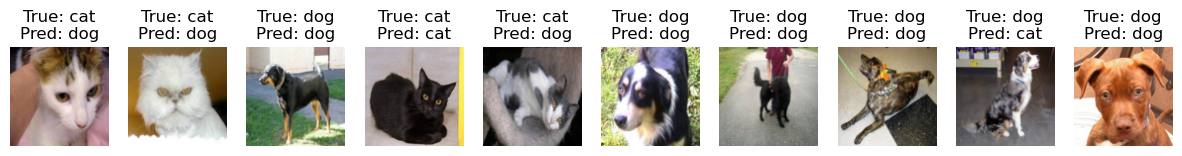

In [14]:
# 예: 테스트 데이터 10개 시각화
visualize_batch_predictions(model, tt_ds_loader, DEVICE, class_names=['cat','dog'], n_images=10)

# CNN

In [52]:
#CNN
class CNN_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # [3, 100, 100]
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # [16, 50, 50]
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # [32, 50, 50]
        self.a_pool = nn.AdaptiveMaxPool2d((7, 7))

        self.fc1 = nn.Linear(32 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        # x = self.pool(F.relu(self.conv2(x)))
        x = self.a_pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        out = self.fc2(x)
        return out

In [40]:
import torch.nn as nn
import torch.nn.functional as F

class CNN_Model(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. 컨볼루션 레이어 정의
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # 2. AdaptiveMaxPool2d 레이어 정의
        # 어떤 크기의 입력이든 7x7 크기의 출력으로 만듭니다.
        # 이 덕분에 fc1의 입력 크기를 고정할 수 있습니다.
        self.adaptive_pool = nn.AdaptiveMaxPool2d((7, 7))

        # 3. 완전 연결 계층(분류기) 정의
        # adaptive_pool의 출력(32 * 7 * 7)을 입력 크기로 설정합니다.
        self.fc1 = nn.Linear(32 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        # 입력: [B, 3, 100, 100]

        # 첫 번째 컨볼루션 블록
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        # 출력: [B, 16, 50, 50]

        # 두 번째 컨볼루션 블록
        x = self.conv2(x)
        x = F.relu(x)
        # 출력: [B, 32, 50, 50]

        # Adaptive Pooling 적용
        x = self.adaptive_pool(x)
        # 출력: [B, 32, 7, 7]

        # Flatten (1차원 벡터로 펼치기)
        x = x.view(x.size(0), -1)
        # 출력: [B, 1568] (1568 = 32 * 7 * 7)

        # 완전 연결 계층 통과
        x = self.fc1(x)
        x = F.relu(x)
        out = self.fc2(x)
        # 최종 출력: [B, 2]

        return out

In [53]:
model = CNN_Model().to(DEVICE)
opt = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)

EPOCHS=10

def train(model, tr_ds_loader, opt, epoch):
    model.train()
    for i,(x,y) in enumerate(tr_ds_loader):
        data, target = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        py = model(data)
        loss = F.cross_entropy(py, target)
        loss.backward()
        opt.step()
        # if i%100==0:
            # print(f"train epoch {epoch} {i*len(data)}/{len(tr_ds_loader.dataset)}({i*100/len(tr_ds_loader):.3f}%) loss:{loss.item():.3f}")

@torch.no_grad() #서식
def evaluate(model, tt_ds_loader):
    model.eval()
    test_loss = 0
    correct = 0
    for data, target in tt_ds_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        py = model(data)
        test_loss += F.cross_entropy(py, target, reduction='sum').item()
        pred = py.max(1, keepdim=True)[1]
        correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(tt_ds_loader.dataset)
    test_accuracy = correct / len(tt_ds_loader.dataset)*100.
    return test_loss, test_accuracy


for i in range(1, EPOCHS+1):
    train(model, tr_ds_loader, opt, i)
    # scheduler.step()
    test_loss, test_accuracy = evaluate(model, tt_ds_loader)

    print(f'epoch: {i}, test_loss: {test_loss:.3f}, test_accuracy: {test_accuracy:.3f}, lr_scheduler: {scheduler.get_last_lr()[0]}')

epoch: 1, test_loss: 0.604, test_accuracy: 68.627, lr_scheduler: 0.01
epoch: 2, test_loss: 0.594, test_accuracy: 70.067, lr_scheduler: 0.01
epoch: 3, test_loss: 0.472, test_accuracy: 77.733, lr_scheduler: 0.01
epoch: 4, test_loss: 0.440, test_accuracy: 79.653, lr_scheduler: 0.01
epoch: 5, test_loss: 0.477, test_accuracy: 77.600, lr_scheduler: 0.01
epoch: 6, test_loss: 0.505, test_accuracy: 75.280, lr_scheduler: 0.01
epoch: 7, test_loss: 0.416, test_accuracy: 81.107, lr_scheduler: 0.01
epoch: 8, test_loss: 0.451, test_accuracy: 78.827, lr_scheduler: 0.01
epoch: 9, test_loss: 0.392, test_accuracy: 82.427, lr_scheduler: 0.01
epoch: 10, test_loss: 0.432, test_accuracy: 81.560, lr_scheduler: 0.01


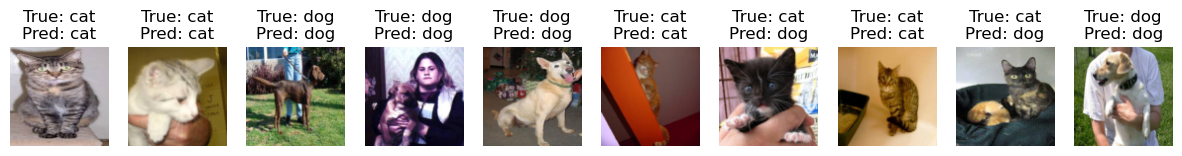

In [55]:
# 예: 테스트 데이터 10개 시각화
visualize_batch_predictions(model, tt_ds_loader, DEVICE, class_names=['cat','dog'], n_images=10)